In [41]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. Define the State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

# 2. Node to calculate BMI
def calculate_bmi(state: BMIState):
    weight = state["weight_kg"]
    height = state["height_m"]
    bmi_val = round(weight / (height**2), 2)
    
    # Return ONLY the key you want to update
    return {"bmi": bmi_val}

# 3. Node to label BMI
def label_bmi(state: BMIState):  # Changed from StateGraph to BMIState
    bmi = state["bmi"]

    if bmi < 18.5:
        cat = "UnderWeight"
    elif 18.5 <= bmi < 25:
        cat = "Normal"
    elif 25 <= bmi < 30:
        cat = "Overweight"
    else:
        cat = "Obese"

    # Return ONLY the key you want to update
    return {"category": cat}

# 4. Build the Graph
workflow = StateGraph(BMIState)

workflow.add_node("calculate", calculate_bmi)
workflow.add_node("label", label_bmi)

workflow.add_edge(START, "calculate")
workflow.add_edge("calculate", "label")
workflow.add_edge("label", END)

app = workflow.compile()

In [43]:
initial_input = {'weight_kg': 65, 'height_m': 1.73}
final_state = app.invoke(initial_input)
print(final_state)

{'weight_kg': 65, 'height_m': 1.73, 'bmi': 21.72, 'category': 'Normal'}


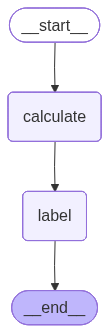

In [47]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())